[Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')]

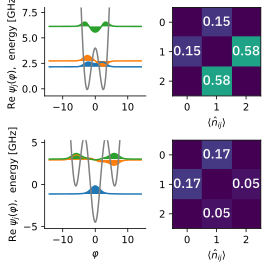

In [33]:
import scqubits
import matplotlib.pyplot as plt
import numpy as np
from scqubits.utils.plotting import add_numbers_to_axes


q1 = scqubits.Fluxonium(4,1,1,0.5,110,6)
q2 = scqubits.Fluxonium(4.5,1.5,0.23,0,110,6)


fig, axes = plt.subplots(2,2,figsize = (4,4))
fig.subplots_adjust(hspace=0.5)

_, wavefunction_ax =  q1.plot_wavefunction(which=[0,1,2], fig_ax=(fig, axes[0,0]))
wavefunction_ax.set_xlabel('')
_, wavefunction_ax =  q2.plot_wavefunction(which=[0,1,2], fig_ax=(fig, axes[1,0]))


from matplotlib.colors import Normalize
norm = Normalize(vmin=0, vmax=1)


import matplotlib as mpl
from scqubits.settings import matplotlib_settings
from matplotlib.axes import Axes
from numpy import ndarray
from typing import Callable
@mpl.rc_context(matplotlib_settings)
def add_numbers_to_axes(
    axes: Axes, matrix: ndarray, modefunc: Callable, fontsize: int = 8
) -> None:
    for y_index in range(matrix.shape[0]):
        for x_index in range(matrix.shape[1]):
            element = np.abs(matrix[y_index, x_index])
            if element < 1e-2:
                string = ''
            else:
                string = f"{element:.2f}"
            axes.text(
                x_index,
                y_index,
                string,
                va="center",
                ha="center",
                fontsize=fontsize,
                rotation=0,
                color="white",
            )


matrix = q1.matrixelement_table('n_operator',evals_count=3)
axes[0,1].imshow(np.abs(matrix), cmap='viridis', norm=norm,aspect='equal')
fig_width, fig_height = fig.get_size_inches()
box_width_inches = fig_width / matrix.shape[1]
box_height_inches = fig_height / matrix.shape[0]
font_size = min(box_width_inches, box_height_inches) * 10
add_numbers_to_axes(axes[0,1], matrix, np.abs, fontsize=font_size)
axes[0,1].set_xlabel(rf"$\leftangle \hat{{n}}_{{ij}} \rightangle$")
axes[0,1].set_xticks([0,1,2])
axes[0,1].set_xticklabels(['0','1','2'])

matrix = q2.matrixelement_table('n_operator',evals_count=3)
axes[1,1].imshow(np.abs(matrix), cmap='viridis', norm=norm,aspect='equal')
fig_width, fig_height = fig.get_size_inches()
box_width_inches = fig_width / matrix.shape[1]
box_height_inches = fig_height / matrix.shape[0]
font_size = min(box_width_inches, box_height_inches) * 10
add_numbers_to_axes(axes[1,1], matrix, np.abs, fontsize=font_size)
axes[1,1].set_xlabel(rf"$\leftangle \hat{{n}}_{{ij}} \rightangle$")
axes[1,1].set_xticks([0,1,2])
axes[1,1].set_xticklabels(['0','1','2'])


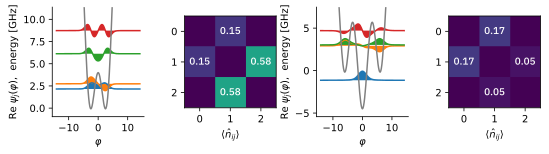

In [34]:
import scqubits
import matplotlib.pyplot as plt
import numpy as np
from scqubits.utils.plotting import add_numbers_to_axes
from matplotlib.colors import Normalize

# Initialize your qubits
q1 = scqubits.Fluxonium(4, 1, 1, 0.5, 110, 6)
q2 = scqubits.Fluxonium(4.5, 1.5, 0.23, 0, 110, 6)

# Create a 1x4 subplot layout
fig, axes = plt.subplots(1, 4, figsize=(7.5, 2), gridspec_kw={'width_ratios': [1, 1, 1, 1]})

# Plot wavefunctions for q1 and q2
_, wavefunction_ax = q1.plot_wavefunction(which=[0, 1, 2, 3], fig_ax=(fig, axes[0]))
# wavefunction_ax.set_xlabel('')
_, wavefunction_ax = q2.plot_wavefunction(which=[0, 1, 2, 3], fig_ax=(fig, axes[2]))

# Normalize the color scale
norm = Normalize(vmin=0, vmax=1)


import matplotlib as mpl
from scqubits.settings import matplotlib_settings
from matplotlib.axes import Axes
from numpy import ndarray
from typing import Callable
@mpl.rc_context(matplotlib_settings)
def add_numbers_to_axes(
    axes: Axes, matrix: ndarray, modefunc: Callable, fontsize: int = 8
) -> None:
    for y_index in range(matrix.shape[0]):
        for x_index in range(matrix.shape[1]):
            element = np.abs(matrix[y_index, x_index])
            if element < 1e-2:
                string = ''
            else:
                string = f"{element:.2f}"
            axes.text(
                x_index,
                y_index,
                string,
                va="center",
                ha="center",
                fontsize=fontsize,
                rotation=0,
                color="white",
            )


# Plot matrix elements for q1
matrix = q1.matrixelement_table('n_operator', evals_count=3)
im = axes[1].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
# fig.colorbar(im, ax=axes[1])  # Optional: Add a colorbar for this heatmap
add_numbers_to_axes(axes[1], matrix, np.abs, fontsize=10)
axes[1].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['0','1','2'])

# Plot matrix elements for q2
matrix = q2.matrixelement_table('n_operator', evals_count=3)
im = axes[3].imshow(np.abs(matrix), cmap='viridis', norm=norm, aspect='equal')
# fig.colorbar(im, ax=axes[3])  # Optional: Add a colorbar for this heatmap
add_numbers_to_axes(axes[3], matrix, np.abs, fontsize=10)
axes[3].set_xlabel(rf"$\langle \hat{{n}}_{{ij}} \rangle$")
axes[3].set_xticks([0,1,2])
axes[3].set_xticklabels(['0','1','2'])

plt.tight_layout(pad=0.1)  # Adjust layout to make sure everything fits without overlapping
plt.show()


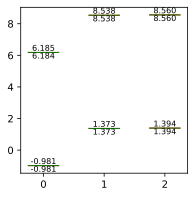

In [60]:
from bidict import bidict
from utils_basic_funcs import generate_single_mapping
qubit = scqubits.Fluxonium(EJ = 2.65,EC = 0.6, EL = 0.13,cutoff=110,truncated_dim=8,flux=0)
resonator =  scqubits.Oscillator(E_osc=7.16518677,truncated_dim=3,l_osc=1.0)

hilbertspace = scqubits.HilbertSpace([qubit, resonator])
hilbertspace.add_interaction(g_strength=0.13,op1=qubit.n_operator, op2=resonator.n_operator,add_hc=False)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
product_to_dressed = bidict(product_to_dressed)

bare_levels = [
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [2,0],
    [2,1]
]
qls = [product[0] for product in bare_levels]
rls = [product[1] for product in bare_levels]
max_qubit_level = max(qls) +1 
max_resonator_level = max(rls) +1
qubit_ori_energies = qubit.eigenvals(max_qubit_level)
resonator_ori_energies = resonator.eigenvals(max_resonator_level)

energy_text_size = 8
fig, ax = plt.subplots(1, 1, figsize=(3, 3))

for ql, rl in zip(qls, rls):
    original = (qubit_ori_energies[ql] + resonator_ori_energies[rl])#* 2 * np.pi
    x1,x2 = ql-0.25,ql+0.25
    ax.plot([x1, x2], [original, original], linewidth=1, color='red')
    ax.text(ql, original, f"{original:.3f}", fontsize=energy_text_size, ha='center', va='bottom')

    dressed_state_index = product_to_dressed[(ql,rl)]
    dressed = hilbertspace.energy_by_dressed_index(dressed_state_index)#* 2 * np.pi
    ax.plot([x1, x2], [dressed, dressed], linewidth=1, color='green')
    ax.text(ql, dressed, f"{dressed:.3f}", fontsize=energy_text_size, ha='center', va='top')

plt.show()


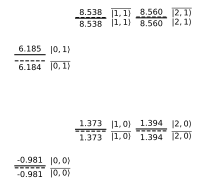

In [112]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

for ql, rl in zip(qls, rls):
    original = (qubit_ori_energies[ql] + resonator_ori_energies[rl])#* 2 * np.pi
    x1,x2 = ql-0.25,ql+0.25
    ax.plot([x1, x2], [original, original], linewidth=1, color='black',linestyle = '-')
    ax.text(ql, original+0.1, f"{original:.3f}", fontsize=energy_text_size, ha='center', va='bottom')
    


    dressed_state_index = product_to_dressed[(ql,rl)]
    dressed_value = hilbertspace.energy_by_dressed_index(dressed_state_index)#* 2 * np.pi
    delta = dressed_value-original
    dressed_plot_value = dressed_value + delta * 500
    ax.plot([x1, x2], [dressed_plot_value, dressed_plot_value], linewidth=1, color='black',linestyle = '--')
    ax.text(ql, dressed_plot_value-0.2, f"{dressed_value:.3f}", fontsize=energy_text_size, ha='center', va='top')

    if ql == 1 or ql == 2:
        if rl == 0:
            y_adjust = -0.3
        else:
            y_adjust = 0.3
    else:
        if rl == 0:
            y_adjust = -0.3
        else:
            y_adjust = -0.3

    dressed_plot_value = dressed_plot_value + y_adjust
    ax.text(ql+0.5, dressed_plot_value, rf"$\overline{{|{ql},{rl}\rangle}}$", fontsize=energy_text_size, ha='center', va='center')

    original_plot_value = original -y_adjust
    ax.text(ql+0.5, original_plot_value, rf"$|{ql},{rl}\rangle$", fontsize=energy_text_size, ha='center', va='center')

ax.set_xticks([])
ax.set_yticks([])

ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

